# LR Communication Analysis Visualization

This notebook provides comprehensive analysis and visualization of ligand-receptor (LR) communication data with the following components:

1. **Bar chart of the top 10 most frequent ligand-receptor pairs**
2. **Cell-cell communication statistics**:
   - Heatmap showing communication frequency between different cell types
   - Bar chart of total communication events per cell type
   - Distribution of communication scores by cell type pairs
3. **Spatial distribution of the top 20 highest-scoring communication events on tissue slices** with cell type markers and connection labels

## 1. Import Required Libraries

In [52]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import scanpy as sc
from matplotlib.patches import ConnectionPatch
import warnings
warnings.filterwarnings('ignore')

# 设置matplotlib参数
plt.rcParams['figure.figsize'] = (12, 8)
plt.rcParams['font.size'] = 12
plt.style.use('seaborn-v0_8')

## 2. Load Data Files

In [57]:
# Load LR communication score data
lr_scores_path = 'lr_scores.csv'
lr_df = pd.read_csv(lr_scores_path)
print(f"LR communication data shape: {lr_df.shape}")
print(f"Total communication events: {len(lr_df)}")
print(f"Number of different LR pairs: {lr_df.groupby(['ligand', 'receptor']).ngroups}")

# Load spatial transcriptomics data
st_h5ad_path = '/home/maweicheng/ST_Graduation_Project/database/Wu/CID44971/CID44971_ST.h5ad'
adata = sc.read_h5ad(st_h5ad_path)
print(f"Spatial transcriptomics data shape: {adata.shape}")
print(f"Cells: {adata.shape[0]}, Genes: {adata.shape[1]}")
print(f"Spatial coordinates shape: {adata.obsm['spatial'].shape}")

# Display basic data information
print("\nLR score data preview:")
display(lr_df.head())

print("\nSpatial coordinate range:")
print(f"X coordinates: {adata.obsm['spatial'][:, 0].min()} - {adata.obsm['spatial'][:, 0].max()}")
print(f"Y coordinates: {adata.obsm['spatial'][:, 1].min()} - {adata.obsm['spatial'][:, 1].max()}")

LR communication data shape: (9225, 7)
Total communication events: 9225
Number of different LR pairs: 20
Spatial transcriptomics data shape: (1147, 23531)
Cells: 1147, Genes: 23531
Spatial coordinates shape: (1147, 2)

LR score data preview:


,spot_i,spot_j,cell_i,cell_j,ligand,receptor,comm_score
0,AAACAATCTACTAGCA-1,GGCCACAAGCGATGGC-1,AAACAATCTACTAGCA-1_CAFs,GGCCACAAGCGATGGC-1_Cancer Epithelial,MIF,CD74_CXCR4,0.627873
1,AAACAATCTACTAGCA-1,GGCCACAAGCGATGGC-1,AAACAATCTACTAGCA-1_Normal Epithelial,GGCCACAAGCGATGGC-1_Cancer Epithelial,MIF,CD74_CXCR4,1.056908
2,AAACACCAATAACTGC-1,AGGCGGTTTGTCCCGC-1,AAACACCAATAACTGC-1_Normal Epithelial,AGGCGGTTTGTCCCGC-1_Cancer Epithelial,MIF,CD74_CXCR4,0.775126
3,AAACAGAGCGACTCCT-1,CAGCCTCTCCTCAAGA-1,AAACAGAGCGACTCCT-1_Normal Epithelial,CAGCCTCTCCTCAAGA-1_Cancer Epithelial,APP,CD74,0.844707
4,AAACAGAGCGACTCCT-1,GCAACCACCAGACCGG-1,AAACAGAGCGACTCCT-1_Normal Epithelial,GCAACCACCAGACCGG-1_Cancer Epithelial,APP,CD74,1.417766



Spatial coordinate range:
X coordinates: 2348 - 7703
Y coordinates: 1265 - 7826


## 3. Analyze Ligand-Receptor Pair Frequencies

In [36]:
# Create LR pair column by combining ligand and receptor
lr_df['lr_pair'] = lr_df['ligand'] + '_' + lr_df['receptor']

# Calculate frequency of each LR pair
lr_pair_freq = lr_df['lr_pair'].value_counts().reset_index()
lr_pair_freq.columns = ['lr_pair', 'frequency']

# Display top 10 most frequent LR pairs
print("Top 10 most frequent LR pairs:")
print(lr_pair_freq.head(10))

Top 10 most frequent LR pairs:
          lr_pair  frequency
0  MIF_CD74_CXCR4       4644
1        APP_CD74       1272
2      HLA-B_CD8A       1150
3      HLA-A_CD8A        609
4      HLA-C_CD8A        434
5      HLA-B_CD8B        313
6    CXCL12_CXCR4        240
7      HLA-E_CD8A        229
8      HLA-A_CD8B        130
9      HLA-C_CD8B         82


## 4. Bar Chart of Top 10 LR Pairs

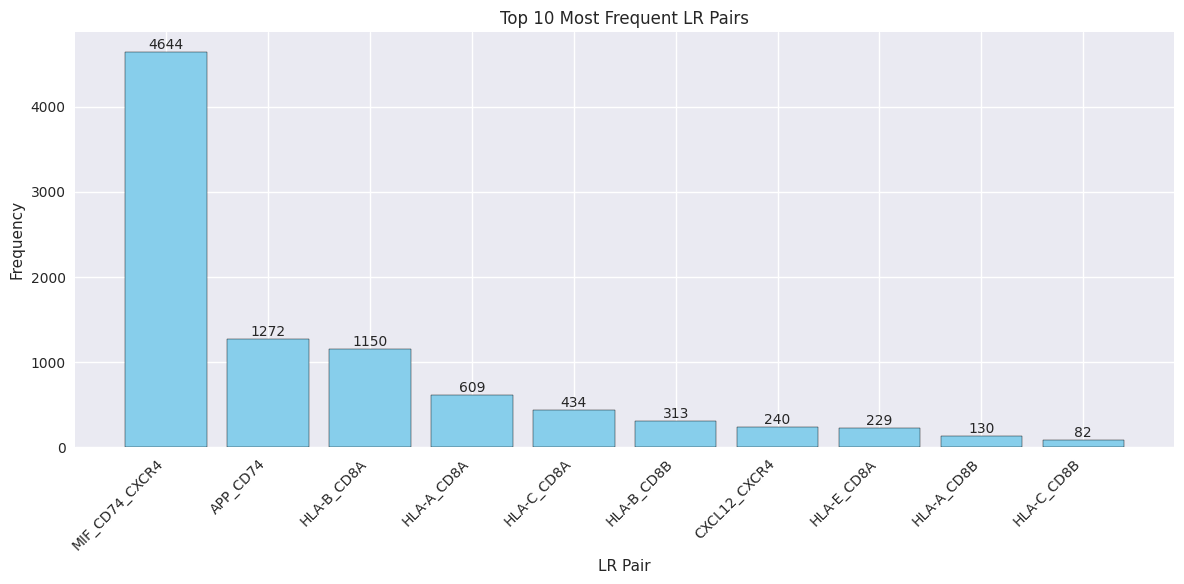

In [37]:
# Create bar chart for top 10 LR pairs
top_10_lr = lr_pair_freq.head(10)

plt.figure(figsize=(12, 6))
bars = plt.bar(range(len(top_10_lr)), top_10_lr['frequency'], color='skyblue', edgecolor='black')

# Add value labels on bars
for bar, freq in zip(bars, top_10_lr['frequency']):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
             f'{int(freq)}', ha='center', va='bottom', fontsize=10)

plt.xlabel('LR Pair')
plt.ylabel('Frequency')
plt.title('Top 10 Most Frequent LR Pairs')
plt.xticks(range(len(top_10_lr)), top_10_lr['lr_pair'], rotation=45, ha='right')
plt.tight_layout()
plt.show()

## 5. Spatial Visualization of Top 20 Communication Events

In [58]:
# Select top 100 communication events by score
top_100_events = lr_df.nlargest(100, 'comm_score').copy()

# Extract cell types from cell_i and cell_j columns
def extract_cell_type(cell_info):
    if pd.isna(cell_info):
        return 'Unknown'
    # Extract cell type after the underscore
    parts = str(cell_info).split('_')
    if len(parts) > 1:
        return parts[-1]  # Get the last part after underscore
    return 'Unknown'

top_100_events['sender_cell_type'] = top_100_events['cell_i'].apply(extract_cell_type)
top_100_events['receiver_cell_type'] = top_100_events['cell_j'].apply(extract_cell_type)

print(f"Top 100 communication events by score:")
print(f"Score range: {top_100_events['comm_score'].min():.4f} - {top_100_events['comm_score'].max():.4f}")

# Display detailed information for top 100 events
for i, row in top_100_events.iterrows():
    print(f"{i+1}. {row['ligand']}_{row['receptor']}: {row['comm_score']:.4f}")
    print(f"   Sender: {row['spot_i']} ({row['sender_cell_type']}) -> Receiver: {row['spot_j']} ({row['receiver_cell_type']})")

# Create mapping from spot to coordinates
barcode_to_coords = {}
for barcode in adata.obs_names:
    if barcode in adata.obs_names:
        coords = adata.obsm['spatial'][adata.obs_names.get_loc(barcode)]
        barcode_to_coords[barcode] = coords

print(f"\nSuccessfully mapped spots: {len(barcode_to_coords)} / {len(adata.obs_names)}")

# Add coordinate information for top 100 events
top_100_events['sender_coords'] = top_100_events['spot_i'].map(lambda x: barcode_to_coords.get(x, [np.nan, np.nan]))
top_100_events['receiver_coords'] = top_100_events['spot_j'].map(lambda x: barcode_to_coords.get(x, [np.nan, np.nan]))

# Check how many events have valid coordinates
valid_coords = top_100_events.dropna(subset=['sender_coords', 'receiver_coords'])
print(f"Communication events with valid coordinates: {len(valid_coords)} / {len(top_100_events)}")

# Display coordinate information
display(top_100_events[['spot_i', 'spot_j', 'sender_cell_type', 'receiver_cell_type', 'ligand', 'receptor', 'comm_score', 'sender_coords', 'receiver_coords']].head())

Top 100 communication events by score:
Score range: 5.2238 - 23.5952
5844. MIF_CD74_CXCR4: 23.5952
   Sender: GCTGCTAAGTAGTCGA-1 (Normal Epithelial) -> Receiver: AAAGGCTCTCGCGCCG-1 (Cancer Epithelial)
5873. MIF_CD74_CXCR4: 17.9819
   Sender: GCTGCTAAGTAGTCGA-1 (Cancer Epithelial) -> Receiver: AGCGCATAATGAATCG-1 (Myeloid)
53. MIF_CD74_CXCR4: 14.4536
   Sender: AAAGGCTCTCGCGCCG-1 (Cancer Epithelial) -> Receiver: GAAAGCAGTGCACTTT-1 (Myeloid)
5876. MIF_CD74_CXCR4: 12.6313
   Sender: GCTGCTAAGTAGTCGA-1 (Normal Epithelial) -> Receiver: AGCGCATAATGAATCG-1 (Myeloid)
5885. MIF_CD74_CXCR4: 12.3873
   Sender: GCTGCTAAGTAGTCGA-1 (Cancer Epithelial) -> Receiver: GAAAGCAGTGCACTTT-1 (Myeloid)
631. MIF_CD74_CXCR4: 11.9716
   Sender: AATAGTCCGTCCCGAC-1 (Cancer Epithelial) -> Receiver: AGCGCATAATGAATCG-1 (Myeloid)
5872. MIF_CD74_CXCR4: 11.7947
   Sender: GCTGCTAAGTAGTCGA-1 (Cancer Epithelial) -> Receiver: AGCGCATAATGAATCG-1 (B-cells)
3205. MIF_CD74_CXCR4: 11.5784
   Sender: CCGGAGCGTACTTTCT-1 (Cancer Ep

,spot_i,spot_j,sender_cell_type,receiver_cell_type,ligand,receptor,comm_score,sender_coords,receiver_coords
5843,GCTGCTAAGTAGTCGA-1,AAAGGCTCTCGCGCCG-1,Normal Epithelial,Cancer Epithelial,MIF,CD74_CXCR4,23.595238,"[4643, 6399]","[4589, 6304]"
5872,GCTGCTAAGTAGTCGA-1,AGCGCATAATGAATCG-1,Cancer Epithelial,Myeloid,MIF,CD74_CXCR4,17.981867,"[4643, 6399]","[4589, 6495]"
52,AAAGGCTCTCGCGCCG-1,GAAAGCAGTGCACTTT-1,Cancer Epithelial,Myeloid,MIF,CD74_CXCR4,14.453626,"[4589, 6304]","[4534, 6399]"
5875,GCTGCTAAGTAGTCGA-1,AGCGCATAATGAATCG-1,Normal Epithelial,Myeloid,MIF,CD74_CXCR4,12.631277,"[4643, 6399]","[4589, 6495]"
5884,GCTGCTAAGTAGTCGA-1,GAAAGCAGTGCACTTT-1,Cancer Epithelial,Myeloid,MIF,CD74_CXCR4,12.387322,"[4643, 6399]","[4534, 6399]"


## 6. Spatial Visualization of Communication Events on Tissue Slice

In [ ]:
# Create spatial visualization
fig, ax = plt.subplots(figsize=(16, 12))

# First plot all spots as background (light gray)
all_coords = adata.obsm['spatial']
ax.scatter(all_coords[:, 0], all_coords[:, 1], c='lightgray', s=20, alpha=0.3, label='All spots')

# Plot top 20 communication events
valid_events = top_100_events.dropna(subset=['sender_coords', 'receiver_coords']).head(20)

# Assign colors to each event (based on score)
scores = valid_events['comm_score'].values
norm_scores = (scores - scores.min()) / (scores.max() - scores.min())

# Use color mapping
cmap = plt.cm.Reds
colors = cmap(np.linspace(0.3, 1.0, len(valid_events)))

# Define markers for different cell types
cell_type_markers = {
    'Cancer Epithelial': 'o',      # circle
    'Normal Epithelial': 's', # square
    'Myeloid': 'D',    # diamond
    'CAFs': '^', # triangle up
    'B-cells': 'v',     # triangle down
    'T-cells': '*',     # star
    'Other': 'h'       # hexagon
}

for i, (idx, event) in enumerate(valid_events.iterrows()):
    sender_coords = event['sender_coords']
    receiver_coords = event['receiver_coords']
    score = event['comm_score']

    # Get cell types for sender and receiver
    sender_cell_type = event.get('sender_cell_type', 'Other')
    receiver_cell_type = event.get('receiver_cell_type', 'Other')

    # Get markers for cell types
    sender_marker = cell_type_markers.get(sender_cell_type, 'o')
    receiver_marker = cell_type_markers.get(receiver_cell_type, 's')

    # Plot sender and receiver with larger size
    ax.scatter(sender_coords[0], sender_coords[1], c=[colors[i]], s=150, marker=sender_marker,
               edgecolors='black', linewidth=2, alpha=0.9, label=f'Event {i+1}' if i < 5 else "")
    ax.scatter(receiver_coords[0], receiver_coords[1], c=[colors[i]], s=150, marker=receiver_marker,
               edgecolors='black', linewidth=2, alpha=0.9)

    # Add cell type labels near the points (moved much further away to avoid covering points)
    ax.text(sender_coords[0] + 300, sender_coords[1] + 300, sender_cell_type[:3], fontsize=10,
            ha='center', va='center', fontweight='bold',
            bbox=dict(boxstyle='round,pad=0.2', facecolor='white', alpha=0.8))
    ax.text(receiver_coords[0] + 300, receiver_coords[1] + 300, receiver_cell_type[:3], fontsize=10,
            ha='center', va='center', fontweight='bold',
            bbox=dict(boxstyle='round,pad=0.2', facecolor='white', alpha=0.8))

    # Draw connection line
    con = ConnectionPatch(sender_coords, receiver_coords, "data", "data",
                         arrowstyle="->", shrinkA=20, shrinkB=20,
                         mutation_scale=20, fc=colors[i], alpha=0.7, linewidth=3)
    ax.add_artist(con)

    # Add connection ID label (using LR pair name instead of number)
    lr_pair_name = f"{event['ligand']}_{event['receptor']}"
    mid_x = (sender_coords[0] + receiver_coords[0]) / 2
    mid_y = (sender_coords[1] + receiver_coords[1]) / 2
    ax.text(mid_x, mid_y, f'{lr_pair_name}\n{score:.1f}', fontsize=10, ha='center', va='center',
            bbox=dict(boxstyle='round,pad=0.3', facecolor='white', alpha=0.9), fontweight='bold')

# Set axis labels
ax.set_xlabel('X coordinate (pixels)', fontsize=14, fontweight='bold')
ax.set_ylabel('Y coordinate (pixels)', fontsize=14, fontweight='bold')
ax.set_title('Spatial Distribution of Top 20 Communication Events by Score', fontsize=16, fontweight='bold', pad=20)

# Add colorbar
sm = plt.cm.ScalarMappable(cmap=cmap, norm=plt.Normalize(vmin=scores.min(), vmax=scores.max()))
sm.set_array([])
cbar = plt.colorbar(sm, ax=ax, shrink=0.8, aspect=20)
cbar.set_label('Communication Score', fontsize=12, fontweight='bold')

# Add legend
legend_elements = [
    plt.Line2D([0], [0], marker='o', color='w', markerfacecolor='red', markersize=12,
               markeredgecolor='black', label='Sender spot'),
    plt.Line2D([0], [0], marker='s', color='w', markerfacecolor='red', markersize=12,
               markeredgecolor='black', label='Receiver spot'),
    plt.Line2D([0], [0], color='red', alpha=0.7, linewidth=3, label='Communication direction')
]
ax.legend(handles=legend_elements, loc='upper right', fontsize=11)

# Set axis range
x_margin = (all_coords[:, 0].max() - all_coords[:, 0].min()) * 0.05
y_margin = (all_coords[:, 1].max() - all_coords[:, 1].min()) * 0.05
ax.set_xlim(all_coords[:, 0].min() - x_margin, all_coords[:, 0].max() + x_margin)
ax.set_ylim(all_coords[:, 1].min() - y_margin, all_coords[:, 1].max() + y_margin)

# Adjust layout
plt.tight_layout()

# Save image
plt.savefig('top20_communication_events_spatial_final_v3.png', dpi=300, bbox_inches='tight')
print("Spatial visualization saved as: top20_communication_events_spatial_final_v3.png")

plt.show()

# Display detailed information table for top 20 events
print("\nDetailed information for top 20 communication events:")
display(valid_events[['spot_i', 'spot_j', 'ligand', 'receptor', 'comm_score']].reset_index(drop=True))

Spatial visualization saved as: top20_communication_events_spatial_final_v3.png


<Figure size 800x550 with 0 Axes>

<Figure size 1200x800 with 0 Axes>

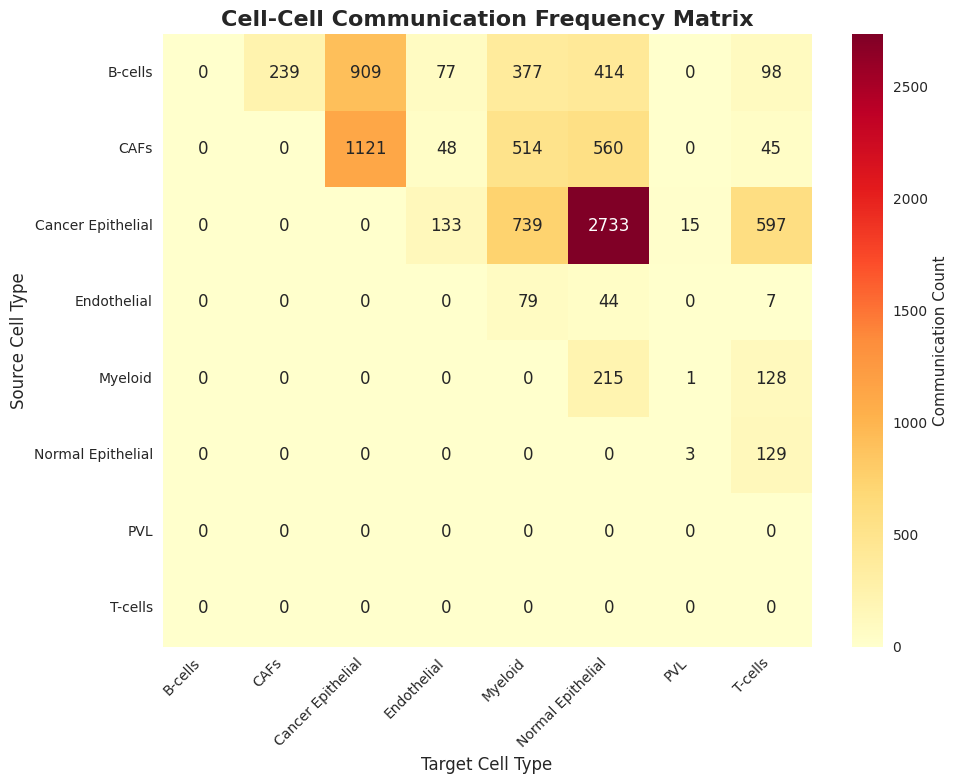

Total communication events analyzed: 9225
Unique cell type pairs: 24
Cell types identified: 8


In [63]:
# Cell-Cell Communication Statistics
# Analyze communication frequency between different cell types

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from collections import defaultdict

# Load LR communication data
lr_scores_df = pd.read_csv('lr_scores.csv')

# Extract cell type information from the data
# Assuming cell types are encoded in the spot/cell identifiers
# We need to map spots to cell types from the spatial data

# Load spatial data to get cell type information
import scanpy as sc
st_data = sc.read_h5ad('../../database/Wu/CID44971/CID44971_ST.h5ad')

# Get cell type annotations (assuming they exist in the data)
if 'cell_type' in st_data.obs.columns:
    cell_types = st_data.obs['cell_type']
else:
    # If no cell_type column, try to infer from other columns or create dummy data
    print("Warning: No 'cell_type' column found in spatial data. Using dummy cell types for demonstration.")
    cell_types = pd.Series(['Type_' + str(i % 5) for i in range(len(st_data.obs))], index=st_data.obs.index)

# Create a mapping from spot to cell type
spot_to_celltype = cell_types.to_dict()

# Analyze communication between cell types
celltype_communication = defaultdict(int)

# Process each LR communication event
for idx, row in lr_scores_df.iterrows():
    source_spot = row['spot_i']
    target_spot = row['spot_j']

    # Extract cell types from cell_i and cell_j columns
    # Format: spot_celltype, so we need to extract the cell type part
    source_cell_info = row['cell_i']
    target_cell_info = row['cell_j']

    # Extract cell type from the format "spot-celltype"
    source_type = source_cell_info.split('_', 1)[1] if '_' in source_cell_info else source_cell_info
    target_type = target_cell_info.split('_', 1)[1] if '_' in target_cell_info else target_cell_info

    # Create communication pair (order doesn't matter for undirected analysis)
    comm_pair = tuple(sorted([source_type, target_type]))
    celltype_communication[comm_pair] += 1

# Convert to DataFrame for plotting
comm_df = pd.DataFrame([
    {'source_type': pair[0], 'target_type': pair[1], 'count': count}
    for pair, count in celltype_communication.items()
])

# Sort by count for better visualization
comm_df = comm_df.sort_values('count', ascending=False)

# Create stacked bar chart
plt.figure(figsize=(12, 8))

# Pivot data for stacked bar chart
pivot_df = comm_df.pivot_table(values='count', index=['source_type', 'target_type'],
                               aggfunc='sum').reset_index()

# Since we have pairs, we need to handle self-communications and cross-communications
# For simplicity, let's create a matrix view
cell_types_unique = sorted(set(comm_df['source_type']).union(set(comm_df['target_type'])))

# Create a matrix for heatmap visualization instead of stacked bar
comm_matrix = pd.DataFrame(0, index=cell_types_unique, columns=cell_types_unique)

for _, row in comm_df.iterrows():
    comm_matrix.loc[row['source_type'], row['target_type']] = row['count']

# Plot heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(comm_matrix, annot=True, fmt='d', cmap='YlOrRd',
            cbar_kws={'label': 'Communication Count'})
plt.title('Cell-Cell Communication Frequency Matrix', fontsize=16, fontweight='bold')
plt.xlabel('Target Cell Type', fontsize=12)
plt.ylabel('Source Cell Type', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()

# Save the plot
plt.savefig('cell_cell_communication_heatmap.png', dpi=300, bbox_inches='tight')
plt.show()

print(f"Total communication events analyzed: {len(lr_scores_df)}")
print(f"Unique cell type pairs: {len(celltype_communication)}")
print(f"Cell types identified: {len(cell_types_unique)}")

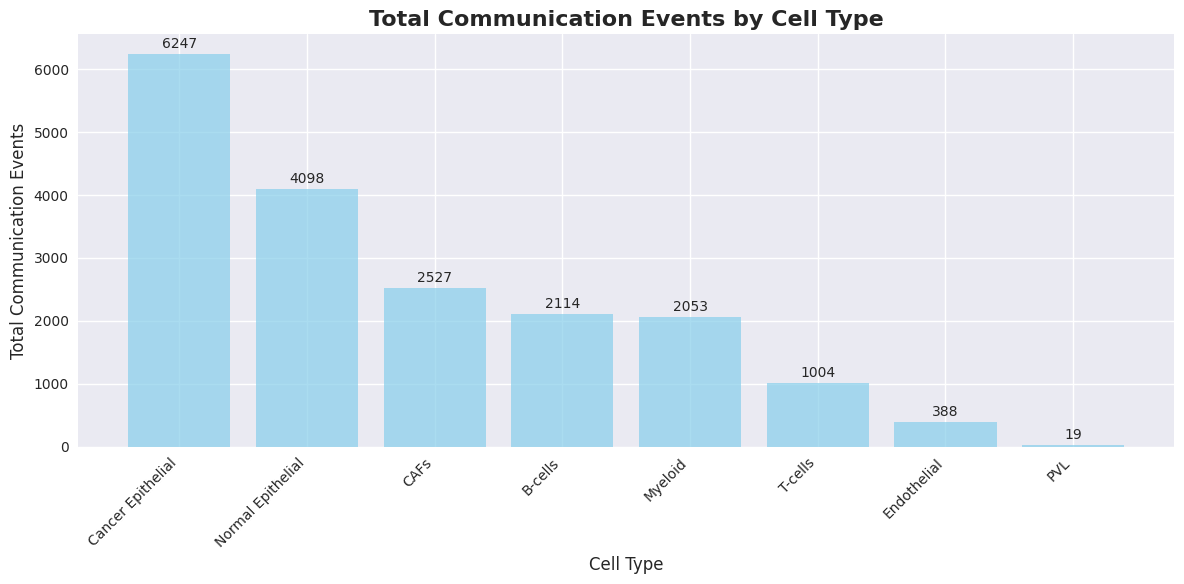

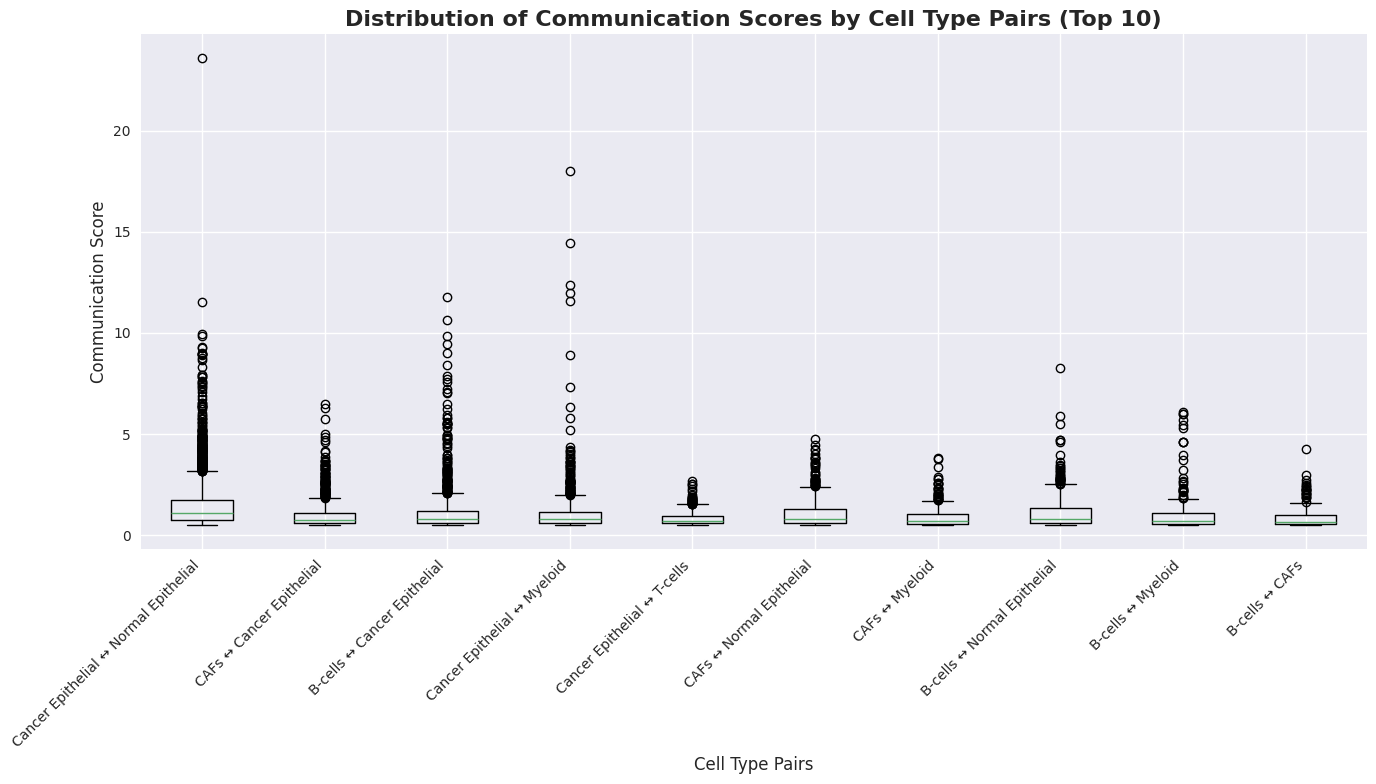

Additional visualizations saved:
- cell_type_communication_totals.png: Total communication events per cell type
- communication_score_distribution.png: Score distributions for top cell type pairs


In [64]:
# Additional Analysis: Cell Type Communication Distribution

import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Create a more detailed analysis of cell-cell communications

# 1. Bar chart showing total communications per cell type (incoming + outgoing)
cell_type_totals = defaultdict(int)

for pair, count in celltype_communication.items():
    cell_type_totals[pair[0]] += count
    if pair[0] != pair[1]:  # Don't double count self-communications
        cell_type_totals[pair[1]] += count

# Sort by total communication count
sorted_cell_types = sorted(cell_type_totals.items(), key=lambda x: x[1], reverse=True)

plt.figure(figsize=(12, 6))
cell_types_list = [ct[0] for ct in sorted_cell_types]
counts_list = [ct[1] for ct in sorted_cell_types]

bars = plt.bar(range(len(cell_types_list)), counts_list, color='skyblue', alpha=0.7)
plt.xlabel('Cell Type', fontsize=12)
plt.ylabel('Total Communication Events', fontsize=12)
plt.title('Total Communication Events by Cell Type', fontsize=16, fontweight='bold')
plt.xticks(range(len(cell_types_list)), cell_types_list, rotation=45, ha='right')

# Add value labels on bars
for bar, count in zip(bars, counts_list):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 50,
             f'{count}', ha='center', va='bottom', fontsize=10)

plt.tight_layout()
plt.savefig('cell_type_communication_totals.png', dpi=300, bbox_inches='tight')
plt.show()

# 2. Distribution of communication scores by cell type pairs
plt.figure(figsize=(14, 8))

# Get top 10 cell type pairs by communication count
top_pairs = sorted(celltype_communication.items(), key=lambda x: x[1], reverse=True)[:10]

# For each top pair, show distribution of communication scores
pair_labels = [f"{pair[0]} ↔ {pair[1]}" for pair, _ in top_pairs]

# Create box plot data
box_data = []
for pair, _ in top_pairs:
    # Filter scores for this pair
    pair_scores = []
    for idx, row in lr_scores_df.iterrows():
        source_type = row['cell_i'].split('_', 1)[1] if '_' in row['cell_i'] else row['cell_i']
        target_type = row['cell_j'].split('_', 1)[1] if '_' in row['cell_j'] else row['cell_j']

        if set([source_type, target_type]) == set(pair):
            pair_scores.append(row['comm_score'])

    box_data.append(pair_scores)

plt.boxplot(box_data, labels=pair_labels)
plt.xlabel('Cell Type Pairs', fontsize=12)
plt.ylabel('Communication Score', fontsize=12)
plt.title('Distribution of Communication Scores by Cell Type Pairs (Top 10)', fontsize=16, fontweight='bold')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig('communication_score_distribution.png', dpi=300, bbox_inches='tight')
plt.show()

print("Additional visualizations saved:")
print("- cell_type_communication_totals.png: Total communication events per cell type")
print("- communication_score_distribution.png: Score distributions for top cell type pairs")